# Step 1: Import Libraries

In [1]:
import os
import zipfile
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

We need os and shutil to manage folders, zipfile to extract the dataset, and keras layers to build the `CNN`

# Step 2: Train and test

In [2]:
# i have existing folder
cats = 'raw_data/Cat_Dog Data Set/cats'
dogs  = 'raw_data/Cat_Dog Data Set/dogs'

# check how many images 
print('Total Cats:', len(os.listdir(cats)))
print('Total Dogs:', len(os.listdir(dogs)))

Total Cats: 1000
Total Dogs: 1000


In [3]:
# Create train test directory structure
base_dir = 'cats_and_dogs'

for split in ['train', 'test']:
    for cls in ['cats', 'dogs']:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Get all image filenames
cat_images = sorted(os.listdir(cats))
dog_images = sorted(os.listdir(dogs))

# Copy cats - 800 train, 200 test
for fname in cat_images[:800]:
    shutil.copy(os.path.join(cats, fname),
               os.path.join(base_dir, 'train', 'cats', fname))

for fname in cat_images[800:1000]:
    shutil.copy(os.path.join(cats, fname),
               os.path.join(base_dir, 'test', 'cats', fname))

# Copy dogs 800 train, 200 test
for fname in dog_images[:800]:
    shutil.copy(os.path.join(dogs, fname),
               os.path.join(base_dir, 'train', 'dogs', fname))

for fname in dog_images[800:1000]:
    shutil.copy(os.path.join(dogs, fname),
               os.path.join(base_dir, 'test', 'dogs', fname))

print('Train cats:', len(os.listdir(os.path.join(base_dir, 'train', 'cats'))))
print('Train Dogs:', len(os.listdir(os.path.join(base_dir, 'train', 'dogs'))))
print('Test cats:', len(os.listdir(os.path.join(base_dir, 'test', 'cats'))))
print('Test dogs:', len(os.listdir(os.path.join(base_dir, 'test', 'dogs'))))

Train cats: 800
Train Dogs: 800
Test cats: 200
Test dogs: 200


# Step 3: Data Augmentation and preprocessgin

In [4]:
# Training  generator - with augmentation
train_datagen = ImageDataGenerator(
    rescale = 1./255,           # Normalize pixel Values from 0-255 to 0-1
    rotation_range=40,          # Randomly rotate images up to 40 degrees
    width_shift_range=0.2,      # Shift image horizontally by 20%
    height_shift_range=0.2,     # Shift image vertically by 20%
    shear_range=0.2,            # apply shearing transformation
    zoom_range=0.2,             # randomly zoom in
    horizontal_flip=True,       # Randomly flip images left-right
    fill_mode='nearest'         # Fill any empty pixels after transform
)

# Test generator - Only rescale, No Augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

Augmentation artificially enlarges  the training set by creating modified versions ofthe same  images,
This reduces overfitting. We never Augment the test data - we only normalize it.

In [5]:
# Define directory Paths
train_dir = 'cats_and_dogs/train'
test_dir = 'cats_and_dogs/test'

#Create Data generators
train_generator = train_datagen.flow_from_directory( # Reada images directly from the folder
    train_dir, 
    target_size=(150, 150), # Resize every image 150 x 150
    batch_size=32,  # instead of loading all 1000 images at once into RAM, it loads 32 at a time memorty efficient
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [6]:
model = Sequential([
    # Block 1 
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    #Block 3
    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    #Block 4
    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    # -- Fully Connected Layer --
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(2, activation='softmax')

])

model.summary()

C:\Users\SACHIN\anaconda3\envs\notebook\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,634 (13.17 MB)

 Trainable params: 3,453,634 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

# Step 5: Compile The Model

In [7]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

# Step 6: Train The Model

In [8]:
history = model.fit(
    train_generator, 
    steps_per_epoch=1600 // 32,
    epochs=30,
    validation_data=test_generator,
    validation_steps=400 // 32
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5263 - loss: 0.6968 - val_accuracy: 0.5286 - val_loss: 0.6903
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 598ms/step - accuracy: 0.5256 - loss: 0.6953 - val_accuracy: 0.5130 - val_loss: 0.6901
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 600ms/step - accuracy: 0.5350 - loss: 0.6898 - val_accuracy: 0.5547 - val_loss: 0.6866
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step - accuracy: 0.5125 - loss: 0.6940 - val_accuracy: 0.5052 - val_loss: 0.6927
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 605ms/step - accuracy: 0.5138 - loss: 0.6917 - val_accuracy: 0.5052 - val_loss: 0.6897
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 757ms/step - accuracy: 0.5288 - loss: 0.6920 - val_accuracy: 0.5651 - val_loss: 0.6872
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 653ms/step - accuracy: 0.5500 - loss: 0.6893 - val_accuracy: 0.6354 - val_loss: 0.6824
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 593ms/step - accuracy: 0.5656 - loss: 0.6857 - val_accurac

# Step 7: Plot Training History


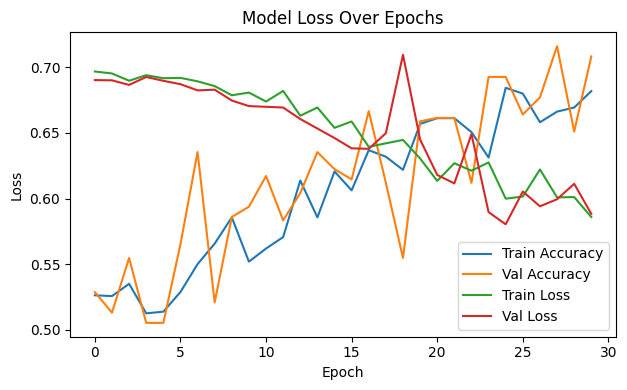

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
history = model.fit(
    train_generator, 
    steps_per_epoch=1600 // 32,
    epochs=50,
    validation_data=test_generator,
    validation_steps=400 // 32
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 557ms/step - accuracy: 0.7175 - loss: 0.5660 - val_accuracy: 0.7188 - val_loss: 0.5657
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 556ms/step - accuracy: 0.7088 - loss: 0.5750 - val_accuracy: 0.7240 - val_loss: 0.5581
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 576ms/step - accuracy: 0.6950 - loss: 0.5774 - val_accuracy: 0.7109 - val_loss: 0.5516
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 558ms/step - accuracy: 0.6988 - loss: 0.5836 - val_accuracy: 0.7135 - val_loss: 0.5586
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 557ms/step - accuracy: 0.7025 - loss: 0.5653 - val_accuracy: 0.7474 - val_loss: 0.5366
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 558ms/step - accuracy: 0.6956 - loss: 0.5755 - val_accuracy: 0.7135 - val_loss: 0.5829
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 561ms/step - accuracy: 0.6950 - loss: 0.5858 - val_accuracy: 0.7266 - val_loss: 0.5639
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 563ms/step - accuracy: 0.6963 - loss: 0.5753 - val_accu

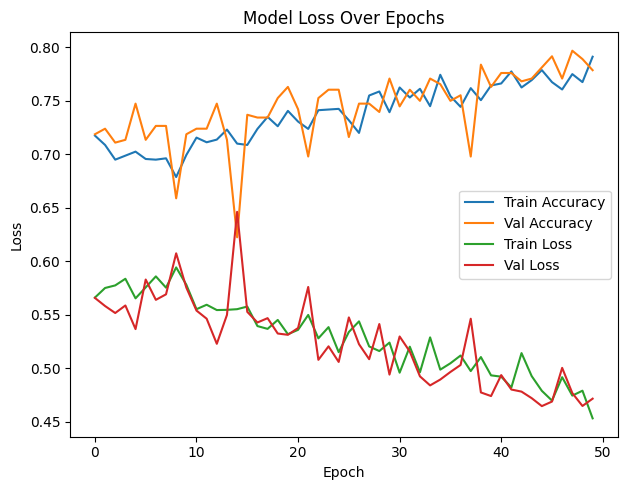

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Step 8: Evaluate on Test Set

In [12]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc * 100:.2f}')
print(f'Test Loss: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.7700 - loss: 0.4795
Test Accuracy: 77.00
Test Loss: 0.4795


# Step 9: Predict on a New  Image

In [32]:
import numpy as np
def predict_image(img_path):

    # Step 1: Load and resize the image
    img = load_img(img_path, target_size=(150,150))

    #Step 2: COnvert to image to numpy array - shape becomes ( 150, 150, 3)
    img_array = img_to_array(img)

    #Step 3 : Normalize Pixel values to 0-1 
    img_array = img_array / 255.0

    # step 4 Add batch dimension - shape becomes (1, 150, 150, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # step 5 Get Predictions
    prediction = model.predict(img_array)

    # index 0 = cats probability index 1 = dogs probabilities

    # Step 6: Get the class with highest probability
    class_idx = np.argmax(prediction[0])

    # Step 7: Map index to label
    
    labels = {0:'Cat', 1:'Dog'}
    
    label = labels[class_idx]
    confidence = prediction[0][class_idx] * 100

    # Step 8: Display image with result
    plt.imshow(load_img(img_path))
    plt.title(f'Prediction: {label} | Confidence: {confidence:.2f}%')
    plt.axis('off')
    plt.show()

    print(f'Predicted Class: {label}')
    print(f'Confidence: {confidence:.2f}%')
    print(f'Raw Probabilities -- Cat: {prediction[0][0]*100:.2f}% Dog: {prediction[0][1]*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


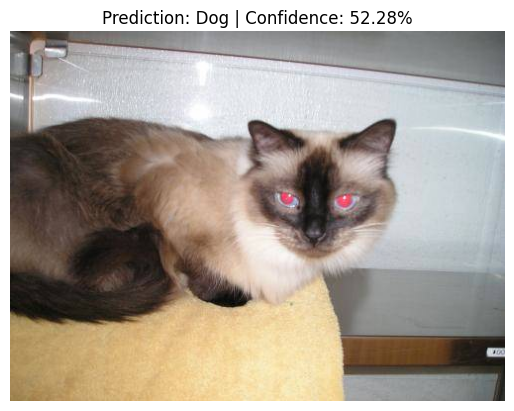

Predicted Class: Dog
Confidence: 52.28%
Raw Probabilities -- Cat: 47.72% Dog: 52.28%


In [34]:
# Replace this with any cat or dog image on your system
predict_image('raw_data/Cat_Dog Data Set/cats/cat.20.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


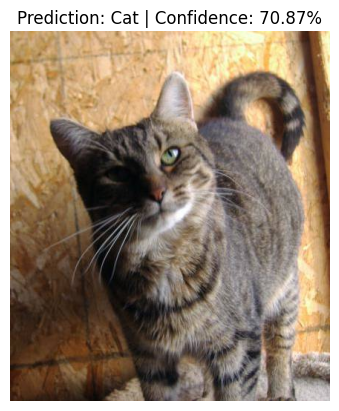

Predicted Class: Cat
Confidence: 70.87%
Raw Probabilities -- Cat: 70.87% Dog: 29.13%


In [35]:
# Replace this with any cat or dog image on your system
predict_image('raw_data/Cat_Dog Data Set/cats/cat.21.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


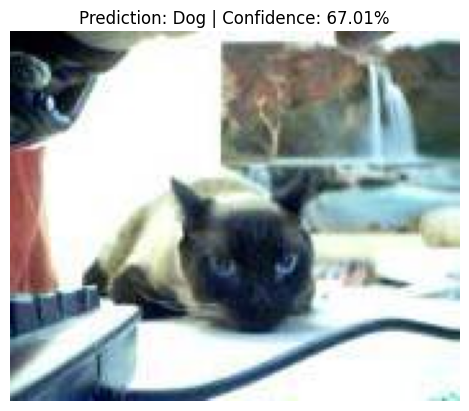

Predicted Class: Dog
Confidence: 67.01%
Raw Probabilities -- Cat: 32.99% Dog: 67.01%


In [36]:
# Replace this with any cat or dog image on your system
predict_image('raw_data/Cat_Dog Data Set/cats/cat.5.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


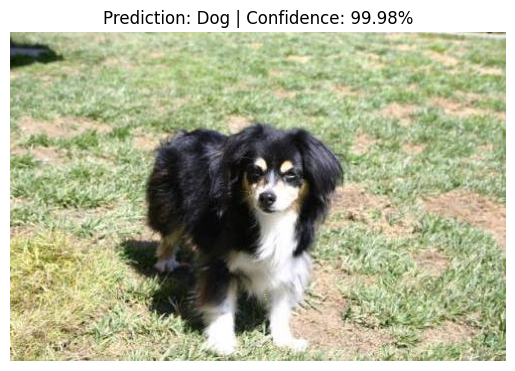

Predicted Class: Dog
Confidence: 99.98%
Raw Probabilities -- Cat: 0.02% Dog: 99.98%


In [37]:
# Replace this with any cat or dog image on your system
predict_image('raw_data/Cat_Dog Data Set/dogs/dog.20.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


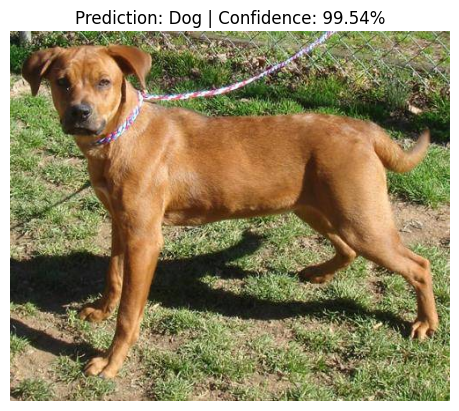

Predicted Class: Dog
Confidence: 99.54%
Raw Probabilities -- Cat: 0.46% Dog: 99.54%


In [38]:
# Replace this with any cat or dog image on your system
predict_image('raw_data/Cat_Dog Data Set/dogs/dog.55.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


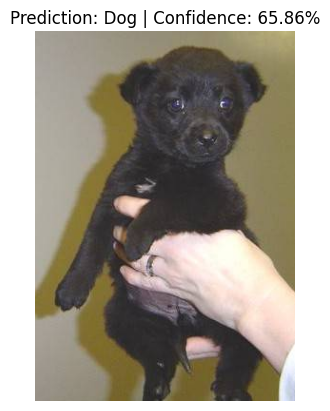

Predicted Class: Dog
Confidence: 65.86%
Raw Probabilities -- Cat: 34.14% Dog: 65.86%


In [39]:
# Replace this with any cat or dog image on your system
predict_image('raw_data/Cat_Dog Data Set/dogs/dog.200.jpg')

# Step 10: Save And  Load the model

In [40]:
model.save('cats_dogs_cnn_model.h5')
print('Model Saved Successfully!')

Model Saved Successfully!


Model Load Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


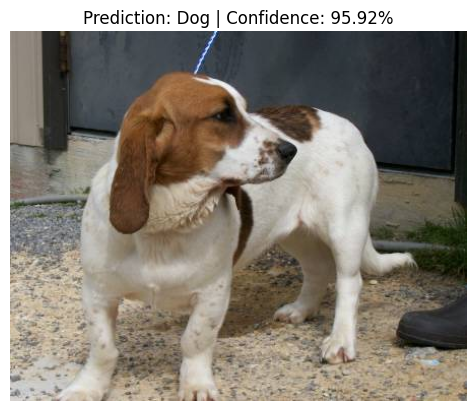

Predicted Class: Dog
Confidence: 95.92%
Raw Probabilities -- Cat: 4.08% Dog: 95.92%


In [42]:
# to load it later in a new session (no need to re)
from tensorflow.keras.models import load_model

model = load_model('cats_dogs_cnn_model.h5')
print('Model Load Successfully')

predict_image('raw_data/Cat_Dog Data Set/dogs/dog.300.jpg')